#📊 Finance AI Asistente Inteligente de Salud Financiera

# 1. Generación del Dataset de Transacciones Financieras y perfil usuarios

Importación de bibliotecas:

In [1]:
import random
import pandas as pd
import numpy as np

random.seed(42)
np.random.seed(42)

Catálogo de Comercios y Rangos de Montos

In [2]:
# Nota: "Starbucks" se quedó solo en Alimentación (ver GASTOS_HORMIGA_KEYWORDS
# más abajo para marcarlo como gasto hormiga sin duplicar categoría).
# "Mantenimiento" se quedó solo en Vivienda.

CATALOGO = {
    "Alimentación": [
        "Walmart", "Soriana", "Chedraui", "Bodega Aurrera", "Costco", "Sam's Club",
        "La Comer", "City Market", "Subway", "Domino's Pizza", "Little Caesars",
        "McDonald's", "Burger King", "Toks", "Vips", "El Globo", "Starbucks",
        "Italianni's", "Sushi Roll", "Chili's", "Mercado", "Despensa"
    ],
    "Transporte": [
        "Uber", "DiDi", "Cabify", "Gasolina Pemex", "Gasolina Shell", "Gasolina BP",
        "Caseta CAPUFE", "ADO", "ETN", "Viva Aerobus", "Aeroméxico",
        "Metro CDMX", "Metrobús"
    ],
    "Salud": [
        "Farmacias Guadalajara", "Farmacias del Ahorro", "Farmacia San Pablo",
        "Hospital Ángeles", "Hospital ABC", "Laboratorio Chopo", "Salud Digna",
        "Dentista", "Ópticas Devlyn", "Ginecólogo"
    ],
    "Vivienda": [
        "Renta", "Hipoteca", "Home Depot", "IKEA", "Mantenimiento",
        "Ferretería", "Pinturas Comex", "Construrama"
    ],
    "Educación": [
        "Coursera", "Platzi", "UNAM", "IPN", "Tec de Monterrey",
        "Compra Libros", "Amazon Libros", "Útiles", "Colegiatura"
    ],
    "Servicios": [
        "CFE", "Telmex", "Totalplay", "Izzi", "Megacable", "Gas Natural",
        "Servicio de Agua", "Telcel", "AT&T"
    ],
    "Entretenimiento": [
        "Cinépolis", "Cinemex", "Steam", "PlayStation Store", "Xbox Store",
        "Nintendo eShop", "Concierto", "Six Flags", "Museo"
    ],
    "Suscripciones": [
        "Netflix", "Spotify", "Disney+", "Amazon Prime", "Max",
        "YouTube Premium", "Google One", "Dropbox", "Apple Music", "Microsoft 365"
    ],
    "Inversión": [
        "CETES", "GBM", "Nu Ahorro", "AFORE", "Fondo Indexado",
        "ETF Vanguard", "Compra Acciones"
    ],

    "Deudas": [
        "Pago TDC BBVA", "Pago TDC Banamex", "Pago TDC Santander",
        "Pago Préstamo Personal", "Liverpool Crédito", "Pago Nómina Kueski"
    ],
    "Seguros": [
        "GNP Seguros", "AXA Seguros", "Seguros Monterrey", "Seguro Auto Qualitas"
    ],
    "Ropa": [
        "Liverpool", "Zara", "H&M", "C&A", "Palacio de Hierro", "Shein"
    ],
    "Mascotas": [
        "Petco", "Veterinario", "PatasPet"
    ],
    "Otros": [
        "Transferencia SPEI", "Compra Desconocida", "Cargo Varios", "OXXO", "7-Eleven"
    ],
}

# Comercios que, aunque pertenecen a una categoría "dueña", se consideran
# gasto hormiga (consumo pequeño y frecuente) — se marca como FLAG, no como
# categoría aparte, para no duplicar etiquetas.
GASTOS_HORMIGA_KEYWORDS = {
    "Starbucks", "Oxxo", "7-Eleven", "Café Punta del Cielo", "Coca-Cola",
    "Sabritas", "Pan Dulce", "Chocolate", "Galletas", "Helado"
}

# Rango de montos realistas por categoría (min, max) en MXN
RANGO_MONTOS = {
    "Alimentación": (60, 900),
    "Transporte": (30, 700),
    "Salud": (100, 3000),
    "Vivienda": (5000, 30000),
    "Educación": (150, 5000),
    "Servicios": (150, 1200),
    "Entretenimiento": (80, 1200),
    "Suscripciones": (49, 299),
    "Inversión": (200, 5000),
    "Deudas": (300, 6000),
    "Seguros": (250, 3500),
    "Ropa": (200, 2500),
    "Mascotas": (100, 1500),
    "Otros": (20, 500),
}

FRECUENCIAS_AHORRO = ["Nula", "Baja", "Media", "Alta"]

Generar transacciones para el usuario

In [3]:
def generar_transacciones_usuario(n_transacciones):
    transacciones = []
    categorias = list(CATALOGO.keys())
    # pesos para que algunas categorías sean más frecuentes (más realista)
    pesos = [18, 12, 6, 5, 4, 10, 8, 8, 3, 6, 3, 6, 3, 8]

    for _ in range(n_transacciones):
        categoria = random.choices(categorias, weights=pesos, k=1)[0]
        comercio = random.choice(CATALOGO[categoria])
        min_monto, max_monto = RANGO_MONTOS[categoria]
        monto = round(np.random.uniform(min_monto, max_monto), 2)
        es_gasto_hormiga = comercio in GASTOS_HORMIGA_KEYWORDS

        transacciones.append({
            "descripcion": comercio,
            "valor": monto,
            "categoria": categoria,  # label para el clasificador de transacciones
            "es_gasto_hormiga": es_gasto_hormiga,
        })
    return transacciones

Calcular el perfil financiero

In [4]:
# =========================================================
# 3. REGLA DE NEGOCIO PARA ETIQUETAR EL PERFIL FINANCIERO
# =========================================================
def calcular_perfil_financiero(ingreso_mensual, nivel_endeudamiento,
                                frecuencia_ahorro, gasto_total):
    ratio_gasto = gasto_total / ingreso_mensual
    puntos_riesgo = 0

    if nivel_endeudamiento > 35:
        puntos_riesgo += 2
    elif nivel_endeudamiento > 18:
        puntos_riesgo += 1

    if ratio_gasto > 0.65:
        puntos_riesgo += 2
    elif ratio_gasto > 0.45:
        puntos_riesgo += 1

    if frecuencia_ahorro == "Nula":
        puntos_riesgo += 2
    elif frecuencia_ahorro == "Baja":
        puntos_riesgo += 1
    elif frecuencia_ahorro == "Alta":
        puntos_riesgo -= 1

    if puntos_riesgo >= 4:
        return "En riesgo"
    elif puntos_riesgo >= 2:
        return "En observación"
    else:
        return "Saludable"


Generar dataset de usuarios y transacciones

In [5]:
def generar_dataset(n_usuarios=300, min_trans=5, max_trans=25,
                     guardar_csv=True):
    filas_transacciones = []
    filas_usuarios = []

    for user_id in range(1, n_usuarios + 1):
        ingreso_mensual = round(np.random.uniform(6000, 60000), 2)
        nivel_endeudamiento = round(np.random.uniform(0, 80), 1)
        frecuencia_ahorro = random.choice(FRECUENCIAS_AHORRO)
        n_transacciones = random.randint(min_trans, max_trans)

        transacciones = generar_transacciones_usuario(n_transacciones)
        gasto_total = sum(t["valor"] for t in transacciones)

        perfil = calcular_perfil_financiero(
            ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro, gasto_total
        )

        for t in transacciones:
            filas_transacciones.append({"user_id": user_id, **t})

        filas_usuarios.append({
            "user_id": user_id,
            "ingreso_mensual": ingreso_mensual,
            "nivel_endeudamiento": nivel_endeudamiento,
            "frecuencia_ahorro": frecuencia_ahorro,
            "gasto_total": round(gasto_total, 2),
            "perfil_financiero": perfil,
        })

    df_transacciones = pd.DataFrame(filas_transacciones)
    df_usuarios = pd.DataFrame(filas_usuarios)

    if guardar_csv:
        df_transacciones.to_csv("dataset_transacciones.csv", index=False)
        df_usuarios.to_csv("dataset_usuarios.csv", index=False)
        print("Archivos guardados: dataset_transacciones.csv, dataset_usuarios.csv")

    return df_transacciones, df_usuarios

Ejecuta el ejemplo

In [6]:
if __name__ == "__main__":
    df_transacciones, df_usuarios = generar_dataset(
        n_usuarios=4000, min_trans=4, max_trans=10
    )

    print("\n--- Transacciones (muestra) ---")
    display(df_transacciones.head())

    print("\n--- Usuarios (muestra) ---")
    display(df_usuarios.head())

    print("\n--- Distribución de perfiles financieros: ---")
    display(df_usuarios["perfil_financiero"].value_counts())

    print("\n--- Distribución de categorías de transacciones: ---")
    display(df_transacciones["categoria"].value_counts())

Archivos guardados: dataset_transacciones.csv, dataset_usuarios.csv

--- Transacciones (muestra) ---


,user_id,descripcion,valor,categoria,es_gasto_hormiga
0,1,Pago TDC Banamex,4472.37,Deudas,False
1,1,Metro CDMX,431.10,Transporte,False
2,1,Italianni's,191.06,Alimentación,False
3,1,Toks,191.04,Alimentación,False
4,2,City Market,564.94,Alimentación,False



--- Usuarios (muestra) ---


,user_id,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,gasto_total,perfil_financiero
0,1,26225.17,76.1,Nula,5285.57,En riesgo
1,2,9136.52,69.3,Nula,6415.53,En riesgo
2,3,50951.90,17.0,Media,4254.22,Saludable
3,4,30627.78,62.8,Media,25699.98,En riesgo
4,5,58144.13,64.7,Nula,6602.70,En riesgo



--- Distribución de perfiles financieros: ---


,count
perfil_financiero,
En observación,1737
Saludable,1195
En riesgo,1068



--- Distribución de categorías de transacciones: ---


,count
categoria,
Alimentación,5098
Transporte,3353
Servicios,2763
Entretenimiento,2250
Otros,2238
Suscripciones,2229
Salud,1725
Ropa,1700
Deudas,1685


#2. EDA (Exploración y limpieza)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_usuarios = pd.read_csv("dataset_usuarios.csv")
df_usuarios.head(10)

,user_id,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,gasto_total,perfil_financiero
0,1,26225.17,76.1,Nula,5285.57,En riesgo
1,2,9136.52,69.3,Nula,6415.53,En riesgo
2,3,50951.90,17.0,Media,4254.22,Saludable
3,4,30627.78,62.8,Media,25699.98,En riesgo
4,5,58144.13,64.7,Nula,6602.70,En riesgo
5,6,19974.12,53.0,Media,11652.67,En observación
6,7,58357.57,62.0,Baja,32582.69,En riesgo
7,8,8442.27,26.0,Baja,34399.33,En riesgo
8,9,59291.89,61.8,Alta,5090.02,Saludable
9,10,47648.60,5.9,Baja,17787.15,Saludable


In [8]:
df_transacciones = pd.read_csv("dataset_transacciones.csv")
df_transacciones.head(10)

,user_id,descripcion,valor,categoria,es_gasto_hormiga
0,1,Pago TDC Banamex,4472.37,Deudas,False
1,1,Metro CDMX,431.10,Transporte,False
2,1,Italianni's,191.06,Alimentación,False
3,1,Toks,191.04,Alimentación,False
4,2,City Market,564.94,Alimentación,False
5,2,CFE,893.48,Servicios,False
6,2,Museo,103.05,Entretenimiento,False
7,2,Útiles,4854.06,Educación,False
8,3,Zara,618.20,Ropa,False
9,3,YouTube Premium,94.85,Suscripciones,False


INSPECCIÓN GENERAL Y LIMPIEZA

In [9]:
print("=" * 60)
print("INSPECCIÓN GENERAL")
print("=" * 60)

print("\n--- Usuarios: info ---")
df_usuarios.info() # Llamar directamente para que imprima su salida

print("\n--- Transacciones: info ---")
df_transacciones.info() # Llamar directamente para que imprima su salida

print("\n--- Valores nulos (usuarios) ---")
display(df_usuarios.isnull().sum())
print("\n--- Valores nulos (transacciones) ---")
display(df_transacciones.isnull().sum())

print("\n--- Duplicados exactos ---")
print(f"Usuarios: {df_usuarios.duplicated().sum()}")
print(f"Transacciones: {df_transacciones.duplicated().sum()}")

# Validaciones de rango (sanity checks financieros)
print("\n--- Validaciones de rango ---")
print(f"Ingresos <= 0: {(df_usuarios['ingreso_mensual'] <= 0).sum()}")
print(f"Endeudamiento fuera de [0,100]: {((df_usuarios['nivel_endeudamiento'] < 0) | (df_usuarios['nivel_endeudamiento'] > 100)).sum()}")
print(f"Transacciones con valor <= 0: {(df_transacciones['valor'] <= 0).sum()}")

INSPECCIÓN GENERAL

--- Usuarios: info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              4000 non-null   int64  
 1   ingreso_mensual      4000 non-null   float64
 2   nivel_endeudamiento  4000 non-null   float64
 3   frecuencia_ahorro    4000 non-null   object 
 4   gasto_total          4000 non-null   float64
 5   perfil_financiero    4000 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 187.6+ KB

--- Transacciones: info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28063 entries, 0 to 28062
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           28063 non-null  int64  
 1   descripcion       28063 non-null  object 
 2   valor             28063 non-null  float64
 3   categoria 

,0
user_id,0
ingreso_mensual,0
nivel_endeudamiento,0
frecuencia_ahorro,0
gasto_total,0
perfil_financiero,0



--- Valores nulos (transacciones) ---


,0
user_id,0
descripcion,0
valor,0
categoria,0
es_gasto_hormiga,0



--- Duplicados exactos ---
Usuarios: 0
Transacciones: 0

--- Validaciones de rango ---
Ingresos <= 0: 0
Endeudamiento fuera de [0,100]: 0
Transacciones con valor <= 0: 0




🔷   **Valores Nulos:**
Tanto df_usuarios como df_transacciones no tienen
ningún valor nulo en ninguna de sus columnas, lo cual es ideal para el análisis y modelado.



🔷   **Duplicados Exactos:**
No se encontraron filas duplicadas exactas en ninguno de los dos DataFrames (df_usuarios y df_transacciones), lo que sugiere que cada registro es único.



🔷  **Validaciones de Rango** (Sanity Checks Financieros): No se encontraron ingresos mensuales menores o iguales a 0.
No se encontraron niveles de endeudamiento fuera del rango de 0 a 100.
No se encontraron transacciones con un valor menor o igual a 0.

DISTRIBUCIÓN DE VARIABLES NUMÉRICAS (usuarios)


--- Estadísticas descriptivas (usuarios) ---


,ingreso_mensual,nivel_endeudamiento,gasto_total
count,4000.000000,4000.000000,4000.000000
mean,32697.706877,40.395075,12489.067827
std,15661.640016,23.119970,11269.878103
min,6002.600000,0.000000,510.330000
25%,18868.125000,20.675000,4826.390000
50%,32973.375000,40.800000,8119.500000
75%,46365.117500,60.400000,17030.567500
max,59962.170000,80.000000,89511.800000


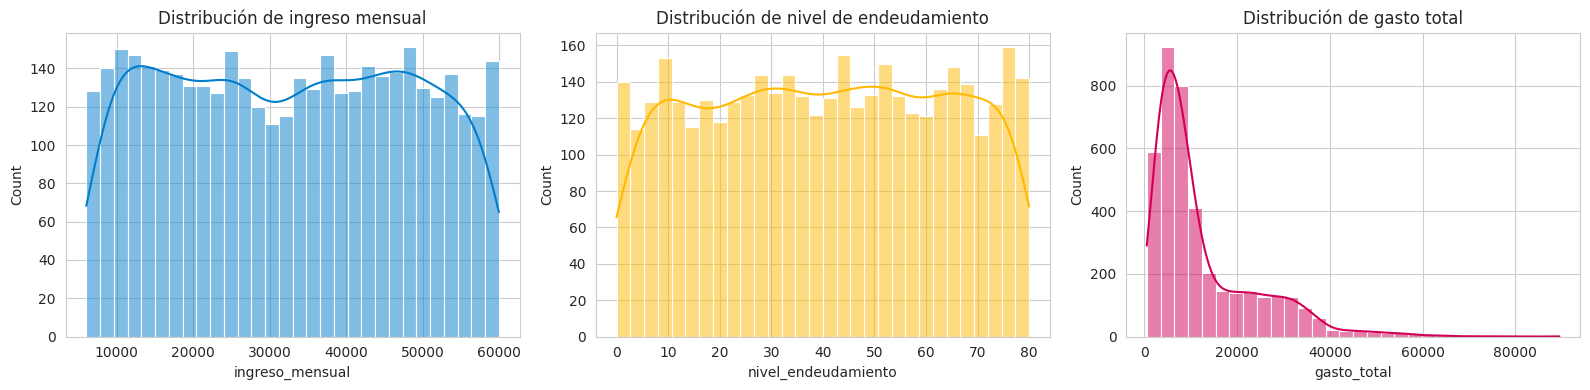


--- Detección de outliers (IQR) ---
ingreso_mensual: 0 outliers fuera de [-22377.4, 87610.6]
nivel_endeudamiento: 0 outliers fuera de [-38.9, 120.0]
gasto_total: 198 outliers fuera de [-13479.9, 35336.8]


In [10]:
print("\n--- Estadísticas descriptivas (usuarios) ---")
display(df_usuarios[["ingreso_mensual", "nivel_endeudamiento", "gasto_total"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_usuarios["ingreso_mensual"], bins=30, ax=axes[0], kde=True, color='#007DCC')
axes[0].set_title("Distribución de ingreso mensual")

sns.histplot(df_usuarios["nivel_endeudamiento"], bins=30, ax=axes[1], kde=True, color='#FFB900')
axes[1].set_title("Distribución de nivel de endeudamiento")

sns.histplot(df_usuarios["gasto_total"], bins=30, ax=axes[2], kde=True, color='#D10056')
axes[2].set_title("Distribución de gasto total")
plt.tight_layout()
plt.savefig("eda_distribuciones_usuarios.png", dpi=100)
plt.show()

# Outliers vía IQR
print("\n--- Detección de outliers (IQR) ---")
for col in ["ingreso_mensual", "nivel_endeudamiento", "gasto_total"]:
    q1, q3 = df_usuarios[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_usuarios[col] < lim_inf) | (df_usuarios[col] > lim_sup)).sum()
    print(f"{col}: {n_outliers} outliers fuera de [{lim_inf:.1f}, {lim_sup:.1f}]")

🔷**Distribución de ingreso mensual:** El histograma muestra una distribución relativamente uniforme del ingreso mensual, con una ligera concavidad en el centro, lo que indica que hay una buena representación de usuarios a lo largo de todo el rango de ingresos generado, desde el mínimo de 6K MXN hasta el máximo de 60K MXN.

🔷**Distribución de nivel de endeudamiento:** Similar al ingreso, el histograma del nivel de endeudamiento también presenta una distribución bastante uniforme entre 0% y 80%. Esto sugiere que el dataset incluye usuarios con diversos niveles de compromisos financieros.

🔷**Distribución de gasto total:** Este histograma muestra una distribución sesgada a la derecha para el gasto total, lo que significa que la mayoría de los usuarios tienen gastos más bajos, con una cola extendida hacia gastos más altos. La mayor concentración de usuarios se encuentra en el rango de gastos más bajos, disminuyendo a medida que aumenta el monto gastado.

🔷**Detección de outliers (IQR):** Se utilizó el método del Rango Intercuartílico (IQR) para identificar outliers. Se encontraron 198 outliers en la variable gasto_total, lo que es consistente con la distribución sesgada a la derecha observada en su histograma. Para ingreso_mensual y nivel_endeudamiento no se detectaron outliers, lo cual se alinea con sus distribuciones más uniformes.

DISTRIBUCIÓN DEL PERFIL FINANCIERO Y FRECUENCIA DE AHORRO

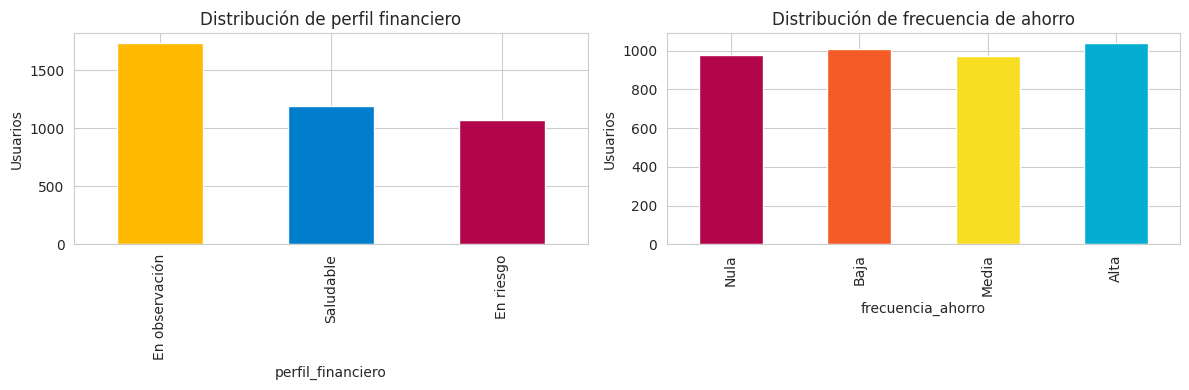


--- Perfil financiero vs. frecuencia de ahorro (%) ---
perfil_financiero  En observación  En riesgo  Saludable
frecuencia_ahorro                                      
Nula                         29.7       70.3        0.0
Baja                         60.7       26.5       12.8
Media                        58.2       11.7       30.1
Alta                         25.7        0.0       74.3


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_usuarios["perfil_financiero"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#FFB900", "#007DCC", "#B2054C"]
)
axes[0].set_title("Distribución de perfil financiero")
axes[0].set_ylabel("Usuarios")

# Definir el orden deseado para la frecuencia de ahorro
orden_frecuencia_ahorro = ['Nula', 'Baja', 'Media', 'Alta']
df_usuarios['frecuencia_ahorro'] = pd.Categorical(df_usuarios['frecuencia_ahorro'], categories=orden_frecuencia_ahorro, ordered=True)

# Colores para la frecuencia de ahorro, según el orden definido
colores_frecuencia_ahorro = ["#B2054C", "#F45B26", "#F8DE22", "#03AED2"]

df_usuarios["frecuencia_ahorro"].value_counts().sort_index().plot(kind="bar", ax=axes[1],
                                                     color=colores_frecuencia_ahorro)
axes[1].set_title("Distribución de frecuencia de ahorro")
axes[1].set_ylabel("Usuarios")
plt.tight_layout()
plt.savefig("eda_perfil_ahorro.png", dpi=100)
plt.show()

# Cruce: perfil financiero vs frecuencia de ahorro (tabla de contingencia)
print("\n--- Perfil financiero vs. frecuencia de ahorro (%) ---")
tabla_cruzada = pd.crosstab(
    df_usuarios["frecuencia_ahorro"], df_usuarios["perfil_financiero"], normalize="index"
) * 100
print(tabla_cruzada.round(1))

🔷**Distribución de perfil financiero:**

El grupo más grande de usuarios se encuentra en la categoría **'En observación'**, lo que sugiere que una parte significativa de la base de usuarios requiere atención para mejorar su salud financiera.

🔷**Distribución de frecuencia de ahorro:**

Las frecuencias de ahorro **'Nula'**, **'Baja'**, **'Media'** y **'Alta'** están distribuidas de manera bastante equilibrada entre los usuarios, con cantidades similares en cada categoría.

🔷**Gasto total y promedio por categoría:**

*   **Vivienda** es, con diferencia, la categoría de mayor gasto, tanto en monto total como en promedio por transacción (17,543.42 MXN).
*   **Deudas** y **Educación** le siguen en gasto total, destacando su importancia en el presupuesto de los usuarios.
*   **Alimentación** tiene el mayor número de transacciones (`count`), lo cual es esperado dado que son gastos cotidianos.
*   Las categorías con menor gasto total y promedio son **Suscripciones** y **Otros**, indicando transacciones de menor valor o menos frecuentes.

🔷**Porcentaje de transacciones marcadas como gasto hormiga:**

*   Aproximadamente el **2.4%** de las transacciones son clasificadas como "gasto hormiga", lo que sugiere que, aunque presentes, no constituyen la mayor parte del volumen transaccional en este conjunto de datos.

PATRONES DE CONSUMO (transacciones)


--- Gasto total y promedio por categoría ---
                 conteo         suma  promedio
categoria                                     
Vivienda           1395  24473069.47  17543.42
Deudas             1685   5301871.24   3146.51
Educación          1151   2914538.70   2532.18
Salud              1725   2699430.90   1564.89
Alimentación       5098   2432271.03    477.10
Ropa               1700   2299098.69   1352.41
Inversión           814   2136263.38   2624.40
Servicios          2763   1845048.05    667.77
Seguros             815   1540617.96   1890.33
Entretenimiento    2250   1424220.60    632.99
Transporte         3353   1231738.66    367.35
Mascotas            847    685477.01    809.30
Otros              2238    583147.08    260.57
Suscripciones      2229    389478.54    174.73


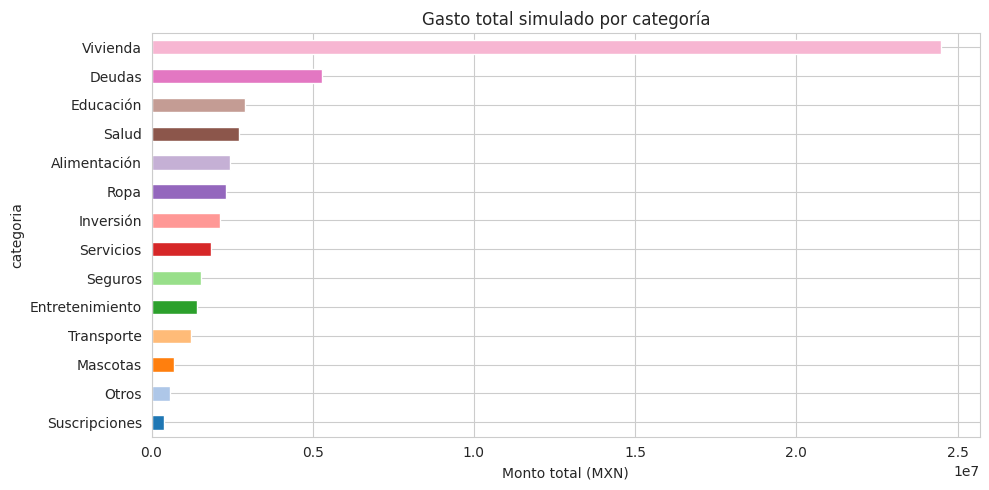


--- % de transacciones marcadas como gasto hormiga ---
es_gasto_hormiga
False    97.6
True      2.4
Name: proportion, dtype: float64


In [12]:
print("\n--- Gasto total y promedio por categoría ---")
resumen_categoria = df_transacciones.groupby("categoria")["valor"].agg(
    ["count", "sum", "mean"]
).sort_values("sum", ascending=False)
resumen_categoria = resumen_categoria.rename(columns={'count': 'conteo', 'sum': 'suma', 'mean': 'promedio'})
print(resumen_categoria.round(2))

plt.figure(figsize=(10, 5))
#paleta de 14 colores distintos (una para cada categoría)
colors = plt.cm.tab20.colors # tab20 tiene 20 colores, suficiente para 14 categorías
resumen_categoria["suma"].sort_values().plot(kind="barh", color=colors[:len(resumen_categoria)])
plt.title("Gasto total simulado por categoría")
plt.xlabel("Monto total (MXN)")
plt.tight_layout()
plt.savefig("eda_gasto_por_categoria.png", dpi=100)
plt.show()

print("\n--- % de transacciones marcadas como gasto hormiga ---")
print(df_transacciones["es_gasto_hormiga"].value_counts(normalize=True).mul(100).round(1))

🔷 **Gasto total y promedio por categoría:**

Vivienda es, con diferencia, la categoría de mayor gasto, tanto en monto total como en promedio por transacción (17,543.42 MXN).
Deudas y Educación le siguen en gasto total, destacando su importancia en el presupuesto de los usuarios.
Alimentación tiene el mayor número de transacciones, lo cual es esperado dado que son gastos cotidianos.
Las categorías con menor gasto total y promedio son Suscripciones y Otros, indicando transacciones de menor valor o menos frecuentes.

🔷 **Porcentaje de transacciones marcadas como gasto hormiga:**
Aproximadamente el 2.4% de las transacciones son clasificadas como "gasto hormiga", lo que sugiere que, aunque presentes, no constituyen la mayor parte del volumen transaccional en este conjunto de datos.

 RELACIÓN ENTRE VARIABLES Y PERFIL FINANCIERO

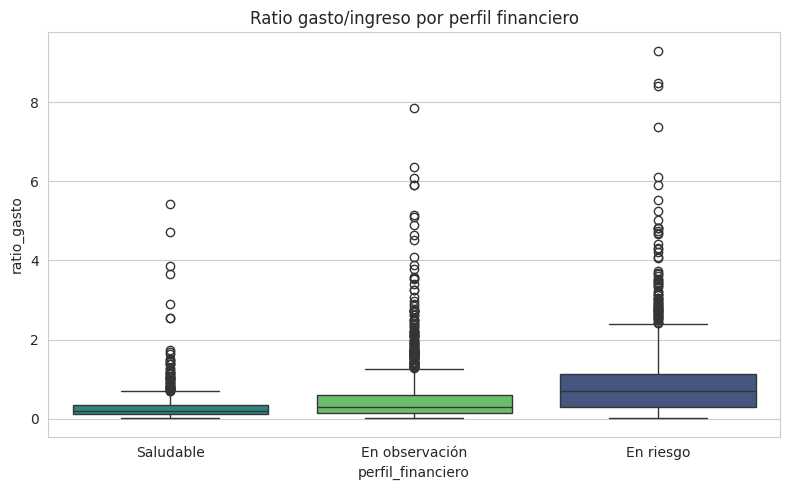

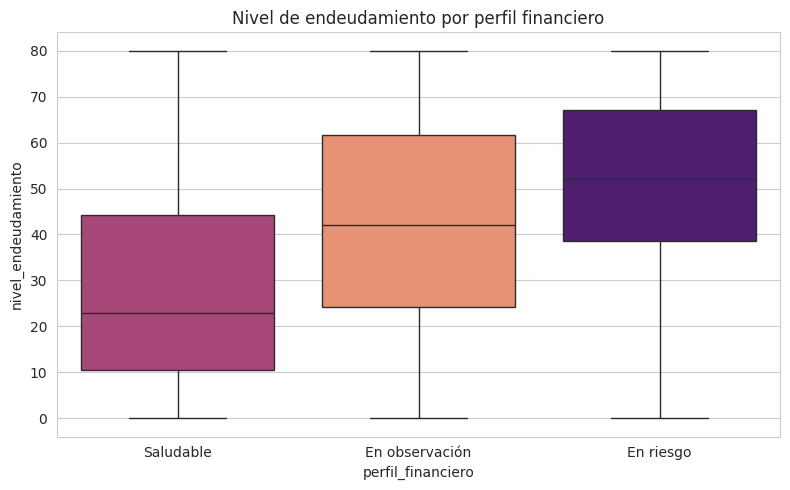

In [13]:
df_usuarios["ratio_gasto"] = df_usuarios["gasto_total"] / df_usuarios["ingreso_mensual"]

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_usuarios, x="perfil_financiero", y="ratio_gasto",
            order=["Saludable", "En observación", "En riesgo"], palette="viridis", hue="perfil_financiero", legend=False)
plt.title("Ratio gasto/ingreso por perfil financiero")
plt.tight_layout()
plt.savefig("eda_ratio_gasto_por_perfil.png", dpi=100)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_usuarios, x="perfil_financiero", y="nivel_endeudamiento",
            order=["Saludable", "En observación", "En riesgo"], palette="magma", hue="perfil_financiero", legend=False)
plt.title("Nivel de endeudamiento por perfil financiero")
plt.tight_layout()
plt.savefig("eda_endeudamiento_por_perfil.png", dpi=100)
plt.show()

🔷 **Ratio gasto/ingreso por perfil financiero:**


*   **Saludable:** Los usuarios en este perfil tienen unratio gasto/ingreso significativamente bajo, lo que indica que gastan una proporción menor de sus ingresos y tienen un mayor margen financiero. Hay pocos outliers y estos no son extremadamente altos.
*   **En observación:** Este perfil muestra un ratio gasto/ingreso más alto que el saludable, con una mayor dispersión y algunos outliers que sugieren casos donde el gasto se acerca o supera el ingreso.


*   **En riesgo:** Como era de esperar, los usuarios 'En riesgo' presentan el ratio gasto/ingreso más elevado, con una gran cantidad de outliers que exceden con creces sus ingresos, lo que subraya su situación de riesgo.


🔷 **Nivel de endeudamiento por perfil financiero:**

*   **Saludable: ** Los usuarios con un perfil financiero 'Saludable' tienen consistentemente los niveles de endeudamiento más bajos, lo que contribuye a su estabilidad financiera.

*   **En observación:** Este grupo tiene niveles de endeudamiento intermedios, con una variabilidad considerable, lo que indica que algunos están en el límite entre un endeudamiento manejable y uno problemático.


*   **En riesgo:** Los usuarios 'En riesgo' muestran los niveles de endeudamiento más altos, reflejando una carga financiera significativa que los coloca en una posición vulnerable.

Matriz de correlación de variables numéricas


--- Matriz de correlación ---


,ingreso_mensual,nivel_endeudamiento,gasto_total,ratio_gasto
ingreso_mensual,1.00,0.01,-0.01,-0.45
nivel_endeudamiento,0.01,1.00,-0.02,-0.02
gasto_total,-0.01,-0.02,1.00,0.69
ratio_gasto,-0.45,-0.02,0.69,1.00


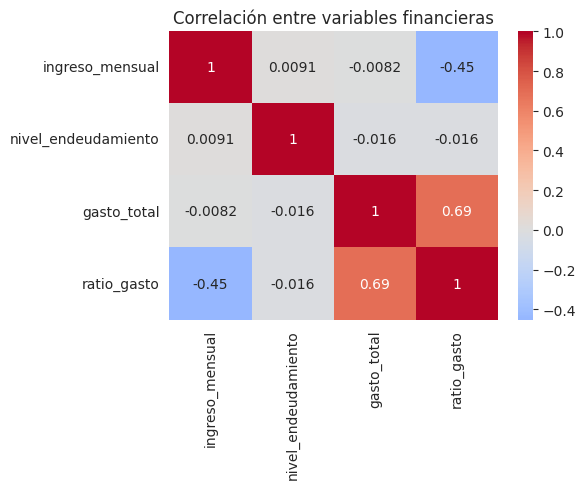


EDA completo. Gráficas guardadas como PNG en el directorio de trabajo.


In [14]:
print("\n--- Matriz de correlación ---")
corr = df_usuarios[["ingreso_mensual", "nivel_endeudamiento", "gasto_total", "ratio_gasto"]].corr()
# Imprimir la tabla de correlación con formato
display(corr.style.background_gradient(cmap='coolwarm').format('{:.2f}'))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlación entre variables financieras")
plt.tight_layout()
plt.savefig("eda_correlacion.png", dpi=100)
plt.show()

print("\nEDA completo. Gráficas guardadas como PNG en el directorio de trabajo.")

**🔷 Matriz de Correlación y Mapa de Calor:**

**Ingreso Mensual:** Muestra una correlación negativa moderada con el ratio_gasto (-0.45). Esto es intuitivo: a mayor ingreso, menor proporción del mismo se destina a gastos, indicando una mejor salud financiera.

**Nivel de Endeudamiento:** Tiene una correlación muy baja con todas las demás variables (cercana a 0). Esto es importante, ya que sugiere que el nivel de endeudamiento es una métrica relativamente independiente del ingreso y el gasto en este dataset, lo cual puede ser útil para identificar perfiles de riesgo no evidentes solo por el gasto o ingreso.

**Gasto Total:** Presenta una correlación positiva fuerte con el ratio_gasto (0.69). Esto tiene sentido, ya que un mayor gasto total, especialmente si no está acompañado por un ingreso proporcionalmente alto, directamente aumenta el ratio de gasto.

#3. Feature Engineering

In [15]:
from sklearn.model_selection import train_test_split

df_usuarios = pd.read_csv("dataset_usuarios.csv")
df_transacciones = pd.read_csv("dataset_transacciones.csv")

# =========================================================
#  MÉTRICAS DE TRANSACCIONES AGREGADAS A NIVEL USUARIO
# =========================================================

# --- 1a. % de gasto por categoría (normalizado, no monto absoluto) ---
# Usamos porcentaje y no el monto en pesos a propósito: así el modelo compara
# el *comportamiento relativo* de cada usuario (a dónde va su dinero) en vez
# de simplemente reaprender el monto total.
gasto_por_categoria = df_transacciones.pivot_table(
    index="user_id", columns="categoria", values="valor", aggfunc="sum", fill_value=0
)
pct_gasto_categoria = gasto_por_categoria.div(gasto_por_categoria.sum(axis=1), axis=0)
pct_gasto_categoria.columns = [f"pct_gasto_{c.lower()}" for c in pct_gasto_categoria.columns]

# --- 1b. Métricas generales de comportamiento por usuario ---
metricas_usuario = df_transacciones.groupby("user_id").agg(
    ticket_promedio=("valor", "mean"),
    std_monto=("valor", "std"),
    frecuencia_transacciones=("valor", "count"),
    num_categorias_distintas=("categoria", "nunique"),
    pct_gasto_hormiga=("es_gasto_hormiga", "mean"),  # ya viene como bool -> mean = %
).reset_index()
metricas_usuario["std_monto"] = metricas_usuario["std_monto"].fillna(0)

# --- 1c. Categoría de mayor gasto (moda) por usuario ---
categoria_top = (
    df_transacciones.loc[df_transacciones.groupby("user_id")["valor"]
                          .idxmax()][["user_id", "categoria"]]
    .rename(columns={"categoria": "categoria_top"})
    .set_index("user_id")
)

# --- 1d. % de gasto en categorías "críticas" (Deudas + gasto hormiga) ---
df_transacciones["es_categoria_riesgo"] = (
    (df_transacciones["categoria"] == "Deudas") | (df_transacciones["es_gasto_hormiga"])
)
pct_gasto_riesgo = (
    df_transacciones.groupby("user_id")
    .apply(lambda g: (g.loc[g["es_categoria_riesgo"], "valor"].sum() / g["valor"].sum()))
    .rename("pct_gasto_riesgo")
)


# =========================================================
#  UNIR TODO A NIVEL USUARIO
# =========================================================
df_features = (
    df_usuarios
    .merge(pct_gasto_categoria, on="user_id", how="left")
    .merge(metricas_usuario, on="user_id", how="left")
    .merge(categoria_top, on="user_id", how="left")
    .merge(pct_gasto_riesgo, on="user_id", how="left")
)

# --- 2a. Codificación ordinal de frecuencia_ahorro ---
# Es una variable ORDINAL (Nula < Baja < Media < Alta), no nominal, así que
# usamos un mapeo numérico en vez de one-hot: preserva el orden natural y
# es más útil para modelos de árboles (Random Forest / Gradient Boosting).
orden_ahorro = {"Nula": 0, "Baja": 1, "Media": 2, "Alta": 3}
df_features["frecuencia_ahorro_ord"] = df_features["frecuencia_ahorro"].map(orden_ahorro)

# --- 2b. One-hot para categoria_top (esta sí es nominal, sin orden natural) ---
df_features = pd.get_dummies(df_features, columns=["categoria_top"], prefix="top")

# =========================================================
#  NOTA SOBRE DATA LEAKAGE
# =========================================================
# gasto_total y ratio_gasto se usaron DIRECTAMENTE en la fórmula que generó
# `perfil_financiero`. Si los dejamos como features tal cual, el modelo no
# aprende nada nuevo: solo memoriza la regla de negocio que ya escribimos
# a mano (accuracy ~100%, pero sin valor real de ML).
#
# Por eso NO los incluimos en X. Sí dejamos nivel_endeudamiento y
# frecuencia_ahorro_ord como features legítimas, porque en un producto real
# esos datos SIEMPRE estarían disponibles antes de calcular el perfil
# (son inputs, no resultados derivados) — la app los pediría al usuario o
# los tomaria del banco, no los calcularía a partir del perfil.
COLUMNAS_EXCLUIDAS = ["user_id", "gasto_total", "perfil_financiero", "frecuencia_ahorro"]

# =========================================================
# 4. MATRIZ X Y VECTOR y
# =========================================================
y = df_features["perfil_financiero"]
X = df_features.drop(columns=COLUMNAS_EXCLUIDAS)

print("Shape de X:", X.shape)
print("Columnas de X:\n", list(X.columns))
print("\nDistribución de y:\n", y.value_counts())

# =========================================================
# 5. TRAIN/TEST SPLIT (estratificado)
# =========================================================
# stratify=y es importante: como las clases no están perfectamente
# balanceadas (ver EDA), sin estratificar el set de prueba podría quedar
# con una proporción distinta a la real y sesgar la evaluación del modelo.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain:", X_train.shape, " Test:", X_test.shape)
print("\nDistribución y_train (%):\n", y_train.value_counts(normalize=True).mul(100).round(1))
print("\nDistribución y_test (%):\n", y_test.value_counts(normalize=True).mul(100).round(1))

# Guardar para el paso de modelado
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
print("\nArchivos guardados: X_train.csv, X_test.csv, y_train.csv, y_test.csv")

Shape de X: (4000, 37)
Columnas de X:
 ['ingreso_mensual', 'nivel_endeudamiento', 'pct_gasto_alimentación', 'pct_gasto_deudas', 'pct_gasto_educación', 'pct_gasto_entretenimiento', 'pct_gasto_inversión', 'pct_gasto_mascotas', 'pct_gasto_otros', 'pct_gasto_ropa', 'pct_gasto_salud', 'pct_gasto_seguros', 'pct_gasto_servicios', 'pct_gasto_suscripciones', 'pct_gasto_transporte', 'pct_gasto_vivienda', 'ticket_promedio', 'std_monto', 'frecuencia_transacciones', 'num_categorias_distintas', 'pct_gasto_hormiga', 'pct_gasto_riesgo', 'frecuencia_ahorro_ord', 'top_Alimentación', 'top_Deudas', 'top_Educación', 'top_Entretenimiento', 'top_Inversión', 'top_Mascotas', 'top_Otros', 'top_Ropa', 'top_Salud', 'top_Seguros', 'top_Servicios', 'top_Suscripciones', 'top_Transporte', 'top_Vivienda']

Distribución de y:
 perfil_financiero
En observación    1737
Saludable         1195
En riesgo         1068
Name: count, dtype: int64

Train: (3200, 37)  Test: (800, 37)

Distribución y_train (%):
 perfil_financiero


/tmp/ipykernel_2836/2385094084.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g.loc[g["es_categoria_riesgo"], "valor"].sum() / g["valor"].sum()))


### Dimensiones y características de los datos

Después del proceso de Feature Engineering, las matrices de características y el vector objetivo tienen las siguientes dimensiones y contenido:

**Shape de X:** `(4000, 37)`

**Columnas de X:**
```
['ingreso_mensual', 'nivel_endeudamiento', 'pct_gasto_alimentación', 'pct_gasto_deudas', 'pct_gasto_educación', 'pct_gasto_entretenimiento', 'pct_gasto_inversión', 'pct_gasto_mascotas', 'pct_gasto_otros', 'pct_gasto_ropa', 'pct_gasto_salud', 'pct_gasto_seguros', 'pct_gasto_servicios', 'pct_gasto_suscripciones', 'pct_gasto_transporte', 'pct_gasto_vivienda', 'ticket_promedio', 'std_monto', 'frecuencia_transacciones', 'num_categorias_distintas', 'pct_gasto_hormiga', 'pct_gasto_riesgo', 'frecuencia_ahorro_ord', 'top_Alimentación', 'top_Deudas', 'top_Educación', 'top_Entretenimiento', 'top_Inversión', 'top_Mascotas', 'top_Otros', 'top_Ropa', 'top_Salud', 'top_Seguros', 'top_Servicios', 'top_Suscripciones', 'top_Transporte', 'top_Vivienda']
```

**Distribución de y:**

In [16]:
display(y.value_counts())

,count
perfil_financiero,
En observación,1737
Saludable,1195
En riesgo,1068


### División en conjuntos de entrenamiento y prueba

La división en conjuntos de entrenamiento y prueba se realizó de manera estratificada para asegurar que la distribución de las clases en el vector objetivo (`y`) se mantenga similar en ambos conjuntos. Esto es crucial cuando se trabaja con clases desbalanceadas para evitar sesgos en la evaluación del modelo.

**Shape de los conjuntos:**
*   Train: `(3200, 37)`
*   Test: `(800, 37)`

**Distribución de `y` en el conjunto de entrenamiento (%):**

In [17]:
display(y_train.value_counts(normalize=True).mul(100).round(1))

,proportion
perfil_financiero,
En observación,43.4
Saludable,29.9
En riesgo,26.7


**Distribución de `y` en el conjunto de prueba (%):**

In [18]:
display(y_test.value_counts(normalize=True).mul(100).round(1))

,proportion
perfil_financiero,
En observación,43.4
Saludable,29.9
En riesgo,26.8


Los archivos `X_train.csv`, `X_test.csv`, `y_train.csv` y `y_test.csv` han sido guardados para su uso en el siguiente paso de modelado.

#ENTRENAMIENTO DE MODELOS

In [43]:
#Agregan bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

CARGA Y PREPARACIÓN DE DATOS

In [44]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()  # .squeeze() para convertir DataFrame en Series
y_test = pd.read_csv('y_test.csv').squeeze()    # .squeeze() ''

# Escalado de características (Crucial para Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODELO BASELINE: REGRESIÓN LOGÍSTICA

In [46]:
print("--- ENTRENANDO MODELO BASELINE (LOGISTIC REGRESSION) ---")
# class_weight='balanced': sin esto, el modelo tiende a favorecer las clases
# mayoritarias (Saludable/En observación) y predice peor "En riesgo", que es
# justo la clase que más nos importa detectar bien.
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Reporte de Clasificación - Regresión Logística:")
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
df_report_lr = pd.DataFrame(report_lr).transpose()
display(df_report_lr.round(2))

--- ENTRENANDO MODELO BASELINE (LOGISTIC REGRESSION) ---
Reporte de Clasificación - Regresión Logística:


,precision,recall,f1-score,support
En observación,0.82,0.74,0.78,347.00
En riesgo,0.82,0.85,0.83,214.00
Saludable,0.81,0.90,0.85,239.00
accuracy,0.82,0.82,0.82,0.82
macro avg,0.82,0.83,0.82,800.00
weighted avg,0.82,0.82,0.81,800.00


MODELO PRINCIPAL: RANDOM FOREST

In [48]:
print("\n--- ENTRENANDO MODELO PRINCIPAL (RANDOM FOREST) ---")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)  # Random Forest no requiere escalado obligatorio

y_pred_rf = rf_model.predict(X_test)

print("Reporte de Clasificación - Random Forest:")
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
df_report_rf = pd.DataFrame(report_rf).transpose()
display(df_report_rf.round(2))


--- ENTRENANDO MODELO PRINCIPAL (RANDOM FOREST) ---
Reporte de Clasificación - Random Forest:


,precision,recall,f1-score,support
En observación,0.89,0.89,0.89,347.00
En riesgo,0.92,0.92,0.92,214.00
Saludable,0.92,0.92,0.92,239.00
accuracy,0.91,0.91,0.91,0.91
macro avg,0.91,0.91,0.91,800.00
weighted avg,0.91,0.91,0.91,800.00


CUADRO COMPARATIVO DE RENDIMIENTO

In [50]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística (Baseline)', 'Random Forest (Principal)'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'F1-Score (Macro)': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]
})

print("\n--- COMPARATIVA DE MODELOS ---")
display(resultados.round(4))


--- COMPARATIVA DE MODELOS ---


,Modelo,Accuracy,F1-Score (Macro)
0,Regresión Logística (Baseline),0.8162,0.8211
1,Random Forest (Principal),0.9062,0.9088


MATRIZ DE CONFUSIÓN Y EXPLICABILIDAD

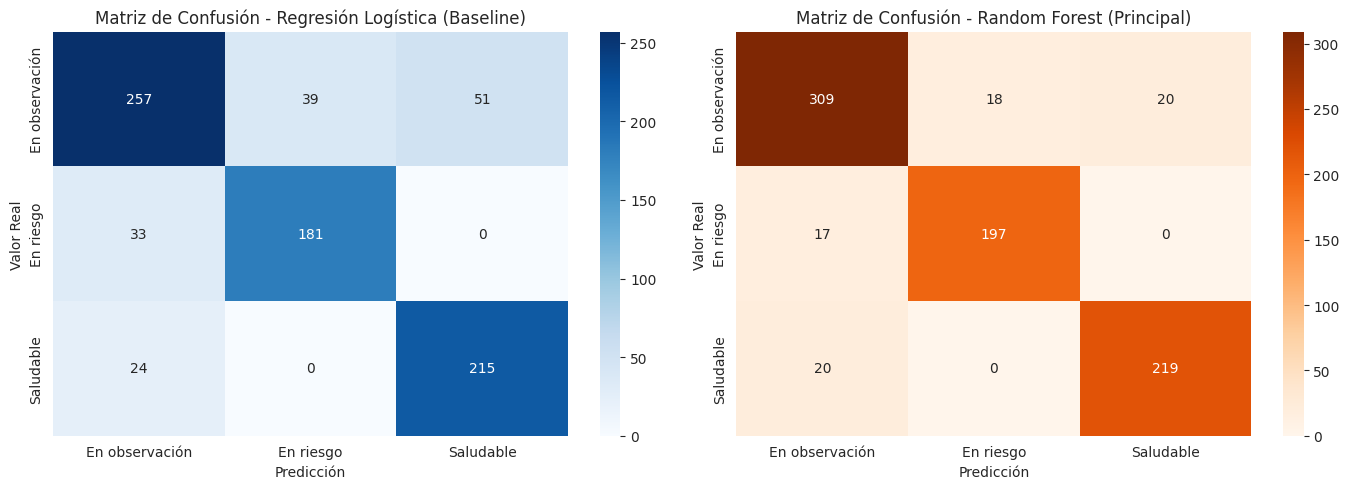

In [55]:
# Gráfico de Matrices de Confusión: Logistic Regression vs. Random Forest,
# lado a lado, para poder mostrar en la presentación cómo mejora el modelo
# principal frente al baseline.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_, yticklabels=lr_model.classes_, ax=axes[0])
axes[0].set_title('Matriz de Confusión - Regresión Logística (Baseline)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, ax=axes[1])
axes[1].set_title('Matriz de Confusión - Random Forest (Principal)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.savefig('matrices_confusion_comparativa.png', dpi=100)
plt.show()

 **Diferencias Clave en las Métricas:
Precisión (Accuracy) General:**

**Regresión Logística:** Tiene una precisión de aproximadamente **81.62%.**

**Random Forest:** Alcanza una precisión significativamente mayor, de **90.62%.** Esto indica que el modelo Random Forest clasifica correctamente una proporción mucho mayor de las instancias totales en comparación con la Regresión Logística.


**F1-Score (Macro):**
**Regresión Logística:** Su F1-Score macro promedio es de 82.11%.

**Random Forest:** Presenta un F1-Score macro promedio superior, de 90.88%. El F1-Score macro es una métrica crucial cuando las clases no están perfectamente balanceadas (como es nuestro caso).

Un F1-Score macro más alto para Random Forest sugiere que este modelo logra un mejor equilibrio entre precisión y recall para cada clase individualmente, lo que es muy deseable para evitar un rendimiento deficiente en clases minoritarias.

**Rendimiento por Clase (Precision, Recall, F1-Score:**

**Mejora Consistente en Random Forest:**
 Si observamos los reportes de clasificación detallados, el modelo Random Forest supera a la Regresión Logística en todas las métricas (precision, recall, f1-score) y para todas las clases ('En observación', 'En riesgo', 'Saludable').

**Clase 'En riesgo':** Ambas métricas son particularmente importantes para la clase 'En riesgo'. Random Forest obtiene un F1-Score de 0.92 para esta clase, mientras que la Regresión Logística obtiene 0.83. Esta mejora es vital, ya que identificar correctamente a los usuarios en riesgo es un objetivo primordial del modelo.


**Clase 'Saludable':** También hay una mejora notable, con Random Forest obteniendo un F1-Score de 0.92 frente a 0.85 de la Regresión Logística.

En resumen, el modelo Random Forest supera consistentemente al modelo de Regresión Logística en todas las métricas de rendimiento clave. Ofrece una precisión general más alta, un mejor equilibrio entre precisión y recall en todas las clases (evidenciado por el F1-Score macro), y una capacidad superior para identificar correctamente a los usuarios en cada perfil financiero, especialmente en la clase 'En riesgo', que es crítica.

In [57]:
import plotly.express as px

# Importancia de TODAS las Características
importancias = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Convertir la serie de importancias a DataFrame para Plotly
importancias_df = importancias.reset_index()
importancias_df.columns = ['Característica', 'Importancia Relativa']

# Crear gráfico interactivo con Plotly
fig = px.bar(importancias_df,
             x='Importancia Relativa',
             y='Característica',
             orientation='h',
             title='Importancia de Variables (Random Forest Explicable - Interactivo)',
             labels={'Importancia Relativa': 'Peso / Importancia Relativa', 'Característica': 'Variable'},
             color='Importancia Relativa', # Colorear por importancia
             color_continuous_scale=px.colors.sequential.Viridis) # Escala de color

fig.update_layout(yaxis={'categoryorder':'total ascending'}) # Ordenar las barras
fig.show()


Las características más influyentes son:

**frecuencia_ahorro_ord:** Esta variable es, con diferencia, la más importante. Su alto valor de importancia relativa indica que la frecuencia con la que un usuario ahorra (Nula, Baja, Media, Alta) es el factor más determinante para predecir su perfil financiero (Saludable, En observación, En riesgo).
Esto es muy intuitivo: un patrón de ahorro consistente es un indicador muy fuerte de una buena salud financiera, y la falta de ahorro es un signo de riesgo.

**nivel_endeudamiento:** Esta es la segunda variable más influyente. El porcentaje de endeudamiento que tiene un usuario es crucial para determinar su perfil. Un alto nivel de endeudamiento está directamente relacionado con un perfil 'En riesgo' o 'En observación', mientras que un bajo nivel sugiere un perfil 'Saludable'.

**ingreso_mensual:** El ingreso mensual también es una característica importante, aunque menos que la frecuencia de ahorro y el nivel de endeudamiento. Lógicamente, un mayor ingreso proporciona una mayor capacidad para cubrir gastos y deudas, lo que influye positivamente en la salud financiera.


SERIALIZACIÓN DEL MODELO (Exportar Botín)

In [58]:
# Backend necesita el modelo guardado para poder consumirlo desde la API.
# Guardamos Random Forest (el de mejor desempeño) y también el scaler,
# porque si en algún momento quieren usar Logistic Regression en producción,
# los datos de entrada deben pasar por el mismo escalado que se usó aquí.
joblib.dump(rf_model, "modelo_perfil_financiero.joblib")
joblib.dump(scaler, "scaler_perfil_financiero.joblib")
print("\nModelo guardado como 'modelo_perfil_financiero.joblib'")
print("Scaler guardado como 'scaler_perfil_financiero.joblib' (solo necesario si se usa Logistic Regression)")


Modelo guardado como 'modelo_perfil_financiero.joblib'
Scaler guardado como 'scaler_perfil_financiero.joblib' (solo necesario si se usa Logistic Regression)
